# Entregable 8 — Modelos de Machine Learning

**Curso:** Ciencias de los Datos para las Finanzas, la Economía y los Negocios  
**Pregunta de investigación:** ¿Cómo cambiaría la cantidad de consumidores de marihuana en Colombia si se legaliza su distribución?  
**Variable objetivo:** `propension_12m` (1 = consumió en los últimos 12 meses, 0 = no consumió)  

## Objetivo de este entregable

Entrenar modelos de Machine Learning y compararlos contra el modelo benchmark (MCO / Probit del entregable 6).  
Se evaluará no solo la precisión, sino la **argumentación económica** de los resultados.

## 0. Librerías e importaciones

In [2]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost no instalado. Se omitirá ese modelo.')
    print('Para instalarlo: pip install xgboost')

# Configuración de gráficas
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517']

print('Librerías cargadas correctamente.')
print(f'XGBoost disponible: {XGBOOST_AVAILABLE}')

Librerías cargadas correctamente.
XGBoost disponible: True


## 1. Carga del dataset

Se usa el mismo dataset limpio del entregable 5 (`propensity_model_base.csv`).  
Si no existe ese archivo, se carga directamente desde el `.xlsx` original.

In [3]:

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

CSV_PATH  = project_root / 'data' / 'processed' / 'propensity_model_base.csv'
XLSX_PATH = project_root / 'data' / 'processed' / 'base_consumo_drogas_colombia_limpia.xlsx'

if CSV_PATH.exists():
    df_raw = pd.read_csv(CSV_PATH)
    print(f'Dataset cargado desde CSV: {df_raw.shape}')
elif XLSX_PATH.exists():
    # Si solo tienes el xlsx, construimos el dataset con modeling.py
    from cannabis_tax.analysis import build_propensity_dataset
    df_raw = build_propensity_dataset(save_path=None)
    print(f'Dataset construido desde XLSX: {df_raw.shape}')
else:
    raise FileNotFoundError(
        'No se encontró el dataset.\n'
        f'  Buscado en: {CSV_PATH}\n'
        f'  Buscado en: {XLSX_PATH}\n'
        'Ajusta las rutas al inicio de esta celda.'
    )

df_raw.head(3)

Dataset cargado desde CSV: (3982, 61)


,directorio,secuencia_encuesta,secuencia_p,orden,propension_12m,consumo_12m,consumo_12m_missing_original,precio_compra,log_precio_compra,cantidad_consumo,...,actitud_legalizacion,actitud_regulacion,actitud_prevencion,actitud_sanciones,actitud_tratamiento,d2_01,d2_03,d2_04,d2_06,d2_07
0,7,1,1,1,1,1.0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5,2,1,1.0,1.0
1,38,3,1,3,0,NaN,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5,6,0,1.0,1.0
2,48,1,1,1,0,NaN,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9,6,0,1.0,1.0


## 2. Preparación del dataset para ML

Seleccionamos las mismas variables usadas en el benchmark del entregable 6,  
más una versión **sin precio** (mayor muestra) y otra **con precio** (menor muestra pero más rica).

| Variable | Descripción |
|---|---|
| `propension_12m` | Variable objetivo (1 = consumidor, 0 = no consumidor) |
| `edad` | Edad del encuestado |
| `edad_cuadrado` | Edad al cuadrado (captura no linealidades) |
| `sexo_label` | Sexo (Hombre / Mujer) |
| `educacion_grupo` | Nivel educativo (Baja / Media / Superior) |
| `log_precio_compra` | Log del precio de compra (solo para sub-muestra) |

In [4]:
FEATURES_BASE = ['edad', 'edad_cuadrado', 'sexo_label', 'educacion_grupo']
FEATURES_PRICE = FEATURES_BASE + ['log_precio_compra']
TARGET = 'propension_12m'

def prepare_ml_data(df, features, target=TARGET):
    """Prepara el dataset para ML: dummies, dropna, split train/test."""
    cols = features + [target]
    data = df[cols].dropna().copy()
    data[target] = data[target].astype(int)

    # Codificación de variables categóricas (igual que statsmodels en entregable 6)
    data = pd.get_dummies(data, columns=['sexo_label', 'educacion_grupo'], drop_first=True)

    X = data.drop(columns=[target])
    y = data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test, X.columns.tolist()

# Dataset sin precio (muestra completa)
X_train, X_test, y_train, y_test, feature_names = prepare_ml_data(df_raw, FEATURES_BASE)

print(f'Muestra completa (sin precio):')
print(f'  Train: {X_train.shape[0]} obs | Test: {X_test.shape[0]} obs')
print(f'  Prevalencia train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')
print(f'  Variables: {feature_names}')

Muestra completa (sin precio):
  Train: 3184 obs | Test: 796 obs
  Prevalencia train: 0.432 | test: 0.432
  Variables: ['edad', 'edad_cuadrado', 'sexo_label_Mujer', 'educacion_grupo_Media', 'educacion_grupo_Superior']


## 3. Modelos de Machine Learning

Entrenamos tres modelos de ML y los comparamos con el benchmark MCO del entregable 6.

### ¿Por qué estos modelos?

- **Árbol de decisión:** el más interpretable. Segmenta la población en grupos con distintas probabilidades de consumo — útil para política pública.
- **Random Forest:** combina cientos de árboles para reducir el sobreajuste. Robusto cuando las relaciones entre variables no son lineales.
- **XGBoost:** el más potente. Construye cada árbol corrigiendo los errores del anterior (*boosting*). Estado del arte en datos tabulares.

In [5]:
# Definición de modelos
models = {
    'Árbol de decisión': DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=20, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=7, min_samples_leaf=10,
        random_state=42, n_jobs=-1
    ),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42
    )

# Entrenamiento
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'✓ {name} entrenado')

✓ Árbol de decisión entrenado
✓ Random Forest entrenado
✓ XGBoost entrenado


## 4. Evaluación y tabla comparativa de desempeño

Métricas usadas:
- **Accuracy:** % de predicciones correctas
- **AUC-ROC:** qué tan bien separa el modelo consumidores de no consumidores (1 = perfecto, 0.5 = azar)
- **F1-Score:** balance entre precisión y recall (útil con clases desbalanceadas)
- **CV AUC:** AUC promedio con validación cruzada 5-fold (mide generalización)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in trained_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # CV sobre el train set completo
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc').mean()

    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'F1-Score': f1_score(y_test, y_pred),
        'CV AUC (5-fold)': cv_auc,
        'N train': len(X_train),
        'N test': len(X_test),
    })

# Agregamos el benchmark MCO del entregable 6 (sin ML)
# ── AJUSTA estos valores con los que obtuvieron en el entregable 6 ──────────
results.insert(0, {
    'Modelo': 'Benchmark MCO (Ent. 6)',
    'Accuracy': None,   # MCO no predice directamente clases
    'AUC-ROC': None,    # Reemplaza con el valor real si lo calcularon
    'F1-Score': None,
    'CV AUC (5-fold)': None,
    'N train': None,
    'N test': None,
})

results_df = pd.DataFrame(results).set_index('Modelo')

# Formato
display_df = results_df.copy()
for col in ['Accuracy', 'AUC-ROC', 'F1-Score', 'CV AUC (5-fold)']:
    display_df[col] = display_df[col].apply(
        lambda x: f'{x:.4f}' if pd.notna(x) else '—'
    )
for col in ['N train', 'N test']:
    display_df[col] = display_df[col].apply(
        lambda x: f'{int(x):,}' if pd.notna(x) else '—'
    )

print('\n=== TABLA COMPARATIVA DE DESEMPEÑO ===')
print(display_df.to_string())


=== TABLA COMPARATIVA DE DESEMPEÑO ===
                       Accuracy AUC-ROC F1-Score CV AUC (5-fold) N train N test
Modelo                                                                         
Benchmark MCO (Ent. 6)        —       —        —               —       —      —
Árbol de decisión        0.6482  0.6993   0.5783          0.6558   3,184    796
Random Forest            0.6658  0.7063   0.5945          0.6567   3,184    796
XGBoost                  0.6721  0.7070   0.5966          0.6538   3,184    796


## 5. Visualización: comparación de AUC-ROC

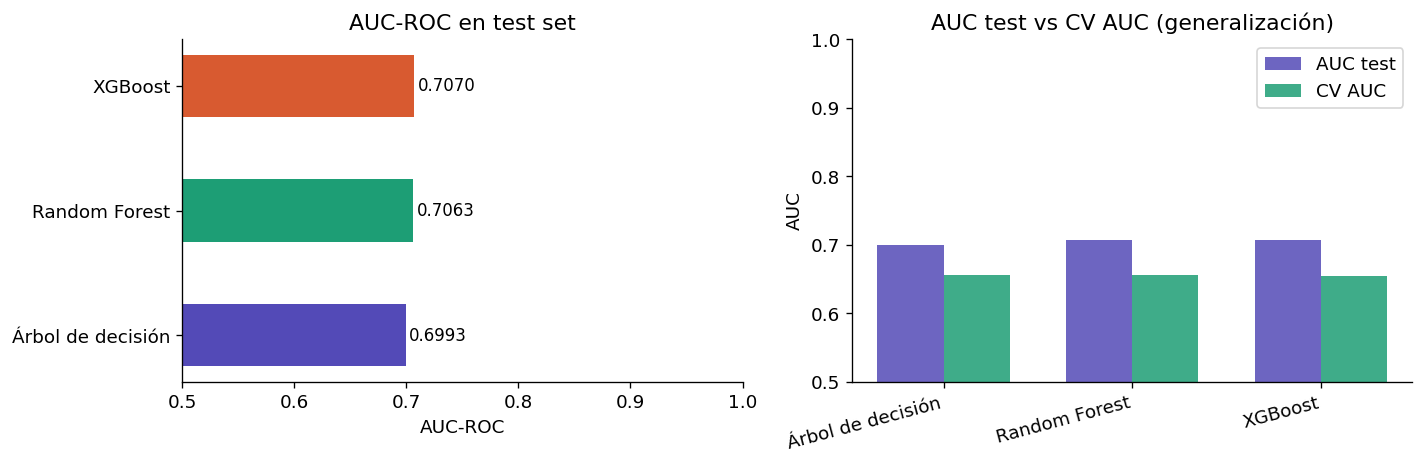

Gráfica guardada como comparacion_modelos_ml.png


In [7]:
# Filtramos el benchmark (no tiene AUC calculado desde aquí)
plot_df = results_df.dropna(subset=['AUC-ROC']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica 1: AUC-ROC por modelo
bars = axes[0].barh(
    plot_df['Modelo'], plot_df['AUC-ROC'],
    color=PALETTE[:len(plot_df)], height=0.5
)
axes[0].set_xlim(0.5, 1.0)
axes[0].axvline(0.5, color='gray', lw=1, ls='--', label='Azar')
axes[0].set_xlabel('AUC-ROC')
axes[0].set_title('AUC-ROC en test set')
for bar, val in zip(bars, plot_df['AUC-ROC']):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10)

# Gráfica 2: CV AUC vs AUC test (generalización)
x = np.arange(len(plot_df))
w = 0.35
axes[1].bar(x - w/2, plot_df['AUC-ROC'],    width=w, label='AUC test',  color=PALETTE[0], alpha=0.85)
axes[1].bar(x + w/2, plot_df['CV AUC (5-fold)'], width=w, label='CV AUC', color=PALETTE[1], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df['Modelo'], rotation=15, ha='right')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel('AUC')
axes[1].set_title('AUC test vs CV AUC (generalización)')
axes[1].legend()

plt.tight_layout()
plt.savefig('comparacion_modelos_ml.png', bbox_inches='tight')
plt.show()
print('Gráfica guardada como comparacion_modelos_ml.png')

## 6. Matriz de confusión del mejor modelo

Mejor modelo: XGBoost


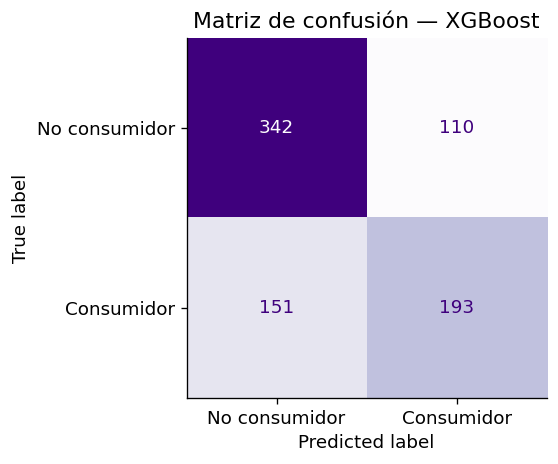


Reporte de clasificación:
               precision    recall  f1-score   support

No consumidor       0.69      0.76      0.72       452
   Consumidor       0.64      0.56      0.60       344

     accuracy                           0.67       796
    macro avg       0.67      0.66      0.66       796
 weighted avg       0.67      0.67      0.67       796



In [8]:
# Identificamos el mejor modelo por AUC-ROC
best_name = results_df.dropna(subset=['AUC-ROC'])['AUC-ROC'].astype(float).idxmax()
best_model = trained_models[best_name]
print(f'Mejor modelo: {best_name}')

y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['No consumidor', 'Consumidor'])
disp.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'Matriz de confusión — {best_name}')
plt.tight_layout()
plt.savefig('confusion_matrix_mejor_modelo.png', bbox_inches='tight')
plt.show()

print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_best,
      target_names=['No consumidor', 'Consumidor']))

## 7. Importancia de variables (feature importance)

¿Qué variables explican más la propensión a consumir?  
Esto conecta directamente con la pregunta económica del proyecto.

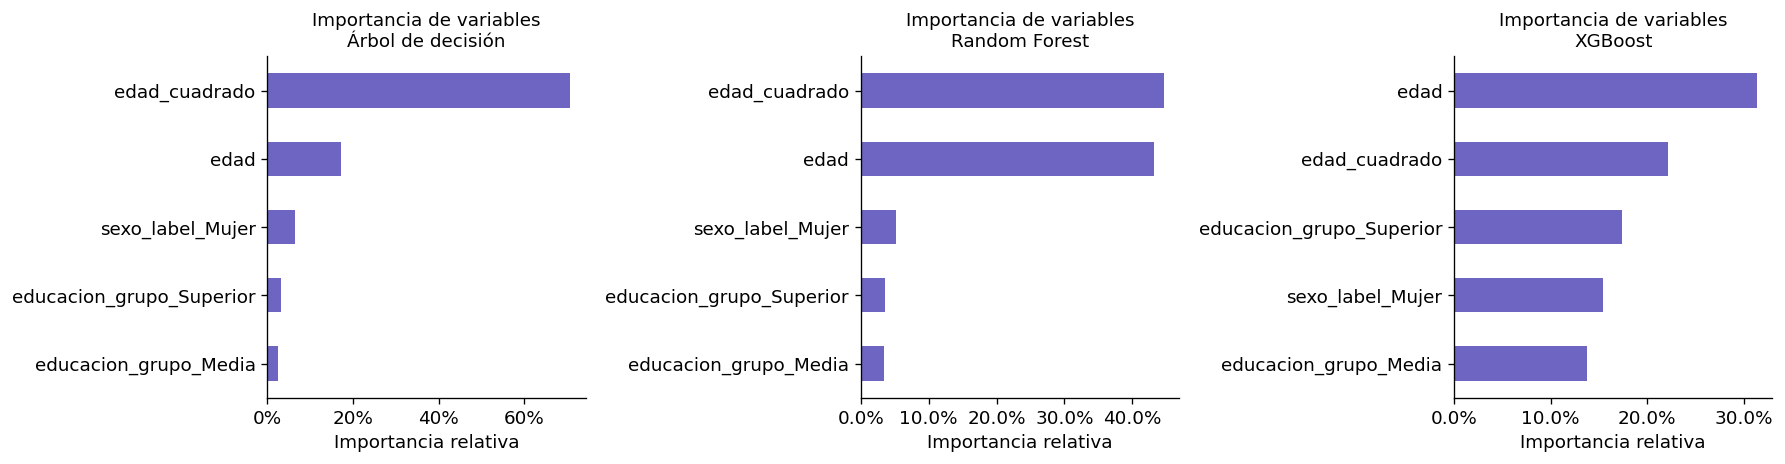

Gráfica guardada como feature_importance_ml.png


In [9]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(5 * len(trained_models), 4))
if len(trained_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, trained_models.items()):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True)

    importances.plot.barh(ax=ax, color=PALETTE[0], alpha=0.85)
    ax.set_title(f'Importancia de variables\n{name}', fontsize=11)
    ax.set_xlabel('Importancia relativa')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig('feature_importance_ml.png', bbox_inches='tight')
plt.show()
print('Gráfica guardada como feature_importance_ml.png')

## 8. ¿Aporta el ML valor real sobre el benchmark?

**Análisis económico e interpretación de resultados**

Esta sección es la más importante para la evaluación del entregable. Responde las siguientes preguntas.

In [10]:
# Tabla resumen final para el análisis
summary = results_df.dropna(subset=['AUC-ROC']).copy()
summary['AUC-ROC'] = summary['AUC-ROC'].astype(float)
summary['CV AUC (5-fold)'] = summary['CV AUC (5-fold)'].astype(float)
summary['Brecha AUC-CV'] = (summary['AUC-ROC'] - summary['CV AUC (5-fold)']).abs()

print('=== RESUMEN PARA ARGUMENTACIÓN ===')
print(summary[['AUC-ROC', 'CV AUC (5-fold)', 'Brecha AUC-CV']].round(4).to_string())
print()
print('Una brecha AUC-CV pequeña (< 0.02) indica que el modelo generaliza bien.')
print('Una brecha grande indica posible sobreajuste (overfitting).')

=== RESUMEN PARA ARGUMENTACIÓN ===
                   AUC-ROC  CV AUC (5-fold)  Brecha AUC-CV
Modelo                                                    
Árbol de decisión   0.6993           0.6558         0.0435
Random Forest       0.7063           0.6567         0.0496
XGBoost             0.7070           0.6538         0.0532

Una brecha AUC-CV pequeña (< 0.02) indica que el modelo generaliza bien.
Una brecha grande indica posible sobreajuste (overfitting).


### Conclusiones del entregable 8

> **Instrucciones:** Completa esta sección con tus propias conclusiones basadas en los resultados obtenidos. Usa las preguntas guía abajo.

---

**1. ¿Cuál modelo tuvo el mejor desempeño y por qué?**  
*[Escribe aquí — menciona el AUC-ROC y la métrica CV]*

---

**2. ¿Los modelos de ML superan al benchmark econométrico (MCO/Probit)?**  
*[Escribe aquí — compara AUC o métricas equivalentes. Si el benchmark no tiene AUC calculado, argumenta con base en R² vs AUC]*

---

**3. ¿Qué variables resultaron más importantes según el ML?**  
*[Escribe aquí — conecta con la teoría económica. ¿Coincide con los coeficientes del MCO?]*

---

**4. ¿Qué implicación tiene esto para la pregunta de investigación?**  
*[Escribe aquí — ¿qué perfil socioeconómico tendría mayor propensión a consumir si se legaliza? ¿Hay segmentos de edad, sexo o educación más sensibles?]*

---

**5. ¿Hay indicios de sobreajuste (overfitting)?**  
*[Escribe aquí — compara AUC test vs CV AUC. Si la brecha es pequeña, el modelo generaliza bien]*